# Target Visibility Checker
- **Cell 1** — imports.  The helper functions live in `helpers.py` beside this
  notebook.
- **Cell 2** — everything you edit: `targets_list`, the UTC start/stop, the
  cadence in minutes, and the `Visibility` instance (default keep-outs).
- **Cell 3** — per-target visibility from `get_visibility_best_roll`, with a
  statistics summary and, for planets, how much of each transit and secondary
  eclipse is observable.
- **Cell 4** — one timeline for all targets: a green line wherever the target
  is visible, over blue transit and purple eclipse boxes.
- **Cell 5** — per-target breakdown of which constraint is failing while the
  target is not visible.

Name a planet rather than a star — `"WASP-107 b"`, `"TRAPPIST-1 b"` — and the
NASA Exoplanet Archive is queried for its ephemeris so transits and secondary
eclipses can be overlaid.  A trailing **lowercase** letter marks the planet; a
trailing uppercase letter is a binary component and stays part of the star
name, so `"WASP-160 B"` is a star and `"WASP-160 B b"` is its planet.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from matplotlib.patches import Patch

from helpers import (
    ECLIPSE_COLOR,
    TRANSIT_COLOR,
    build_time_grid,
    draw_event_box,
    draw_row,
    event_segments,
    event_visibility_stats,
    format_date_axis,
    label_rows,
    mask_segments,
    predict_events,
    prepare_targets,
    run_stats,
)
from pandoravisibility import Visibility

## Edit this cell

`targets_list` accepts star names (looked up in SIMBAD), planet names ending in
a lowercase letter (looked up in SIMBAD *and* the NASA Exoplanet Archive),
decimal-degree pairs, and sexagesimal string pairs — mix them freely.

In [2]:
# Targets
# targets_list = [
#     "GJ 1214",                       # name → looked up in SIMBAD
#     "WASP-80",
#     "TOI-836",
#     "KELT-9",                        # inside the Sun keep-out all day here
#     "WASP-107 b",                    # planet → transit + eclipse overlay
#     "WASP-107 c",                    # known planet, does not transit → warning
#     "WASP-160 B b",                  # planet of the B component of a binary
#     (255.0, 10.0),                   # RA, Dec in decimal degrees
#     ("17h00m00s", "-30d00m00s"),     # RA, Dec as sexagesimal strings
# ]

targets_list = [
    "HD209458 b",
    "WASP-69 b",
    "KELT-9 b",
    "HAT-P-67 b",
    "GJ 12 b ",
    "K2-141 b",
    "KELT-20 b",
    "GJ 9827 b",
    "HD221416 b",
    "TOI-1533 c",
    "WASP-52 b",
    "WASP-127 b"
]

# Time window (UTC) and cadence
start_utc = "2026-08-10T00:00:00"
stop_utc = "2026-08-24T00:00:00"
time_step_minutes = 10.0

# Spacecraft orbit
# Draft TLE for Pandora — use the most up-to-date one for real work!
line1 = "1 67395U 80229J   26212.76861111  .00000000  00000-0  37770-3 0    05"
line2 = "2 67395  97.8073 210.7389 0004787   3.5990  91.5851 14.88172851    02"

# Default keep-outs: Sun ≥ 91°, Moon ≥ 25°, Earth limb ≥ 20°, no star
# tracker limits.  Pass overrides here to tighten anything, e.g.
# Visibility(line1, line2, earthlimb_day_min=45*u.deg, st_sun_min=44*u.deg).
visibility = Visibility(
    line1, line2,
    earthlimb_day_min=44 * u.deg,
    earthlimb_night_min=13 * u.deg,
    sun_min=91 * u.deg,
    moon_min=20 * u.deg,
    st_sun_min=50 * u.deg,
    st_moon_min=20 * u.deg,
    st_earthlimb_min=30 * u.deg,
    st_required=1,
    use_dynamic_earthlimb=True,
    # Sun/Moon evaluated hourly and interpolated instead of at every
    # timestep.  Their directions stay good to well under 0.01 deg, and
    # long multi-target runs get several times faster.  Drop this line to
    # evaluate the ephemeris exactly.
    ephemeris_step=60 * u.min,
)

# Roll sweep settings for get_visibility_best_roll.  These only bite once
# star tracker keep-outs are active, which the defaults leave switched off.
roll_step = 2 * u.deg
orbit_time_step = 1 * u.min

times = build_time_grid(start_utc, stop_utc, time_step_minutes)

print(visibility)
print(f"Orbital period: {visibility.get_period():.2f}")
print(f"{len(times)} steps of {time_step_minutes:g} min: "
      f"{times[0].iso} → {times[-1].iso}")

<Visibility: SAT67395 [moon≥20 deg, sun≥91 deg, limb=dynamic, st_sun≥50 deg, st_moon≥20 deg, st_limb≥30 deg, st_req=1]>
Orbital period: 96.76 min
2016 steps of 10 min: 2026-08-10 00:00:00.000 → 2026-08-23 23:50:00.000


## Visibility per target

`get_visibility_best_roll` picks the best fixed roll angle for each orbit and
reports visibility at every time step.

For any target named as a planet, the transits and secondary eclipses falling
in the window are listed with the fraction of each event that is observable.
Events touching the edge of the window are marked `*`; only the sampled part of
those counts towards the percentage.

In [3]:
targets = prepare_targets(targets_list)
results = {}

header = (
    f"{'Target':<24}{'Visible':>13}{'Duty':>8}{'Windows':>9}{'Longest':>10}"
)
print(header)
print("-" * len(header))

for target in targets:
    label = target["label"]

    best_roll = visibility.get_visibility_best_roll(
        target["coord"], times, roll_step=roll_step, orbit_time_step=orbit_time_step,
    )
    visible = np.asarray(best_roll["visible"])
    n_windows, longest_minutes = run_stats(times, visible, time_step_minutes)

    # Transits and secondary eclipses inside the window, when this target
    # was named as a planet the archive has an ephemeris for.
    events = {}
    if target["ephemeris"] is not None:
        for kind in ("transit", "eclipse"):
            ephemeris = target["ephemeris"][kind]
            if ephemeris is not None:
                events[kind] = predict_events(ephemeris, target["coord"], times)

    results[label] = {
        "coord": target["coord"],
        "visible": visible,
        "best_roll": best_roll,
        "events": events,
    }

    print(
        f"{label:<24}"
        f"{f'{visible.sum()} / {len(times)}':>13}"
        f"{100 * visible.mean():>7.1f}%"
        f"{n_windows:>9}"
        f"{longest_minutes:>8.0f} m"
    )

roll_used = np.concatenate([r["best_roll"]["roll_deg"].ravel() for r in results.values()])
if np.isfinite(roll_used).any():
    print(f"\nMedian roll angle used: {np.nanmedian(roll_used):.1f} deg")
else:
    print("\nNo roll angle selected (no star tracker constraints active).")

# Transit and secondary eclipse coverage
if any(result["events"] for result in results.values()):
    print("\nTransit and secondary eclipse coverage")
    for label, result in results.items():
        for kind, events in result["events"].items():
            if not events:
                print(f"  {label} — no {kind} in this window")
                continue
            stats = event_visibility_stats(events, result["visible"])
            fully = sum(1 for f in stats["fractions"] if f >= 1.0)
            print(
                f"  {label} — {stats['n_events']} {kind}s "
                f"({stats['n_full']} complete), "
                f"{100 * stats['visible_fraction']:.1f}% of {kind} time visible, "
                f"{fully} fully observable"
            )
            for event, fraction in zip(events, stats["fractions"]):
                edge = "*" if event["clipped"] else " "
                print(
                    f"      {event['mid'].iso[:16]} UTC{edge} "
                    f"{event['start'].iso[11:16]}-{event['stop'].iso[11:16]}  "
                    f"{100 * fraction:5.1f}% visible"
                )

N:\Joe Documents\Gits\pandora-visibility\docs\helpers.py:586: UserWarning: GJ 12 b : no such planet in the NASA Exoplanet Archive; keeping the star without transit predictions.
  prepared = [prepare_target(target) for target in targets_list]


Target                        Visible    Duty  Windows   Longest
----------------------------------------------------------------
HD209458 b                1396 / 2016   69.2%      209      80 m
KELT-9 b                   816 / 2016   40.5%      212      50 m
WASP-127 b                   0 / 2016    0.0%        0       0 m
HAT-P-67 b                 613 / 2016   30.4%      328      40 m
GJ 12 b                   1041 / 2016   51.6%      209      60 m
K2-141 b                  1264 / 2016   62.7%      209      70 m
KELT-20 b                  827 / 2016   41.0%      251      50 m
GJ 9827 b                 1256 / 2016   62.3%      209      70 m
HD221416 b                1244 / 2016   61.7%      209      70 m
TOI-1533 c                 690 / 2016   34.2%      209      40 m
WASP-52 b                 1263 / 2016   62.6%      209      70 m

Median roll angle used: -78.0 deg

Transit and secondary eclipse coverage
  HD209458 b — 4 transits (4 complete), 73.0% of transit time visible, 0 fully o

## When is each target visible?

A green line means the target clears every constraint at that time step.  Blue
boxes are transits and purple boxes are secondary eclipses, so green sitting
inside a box is an observable event.

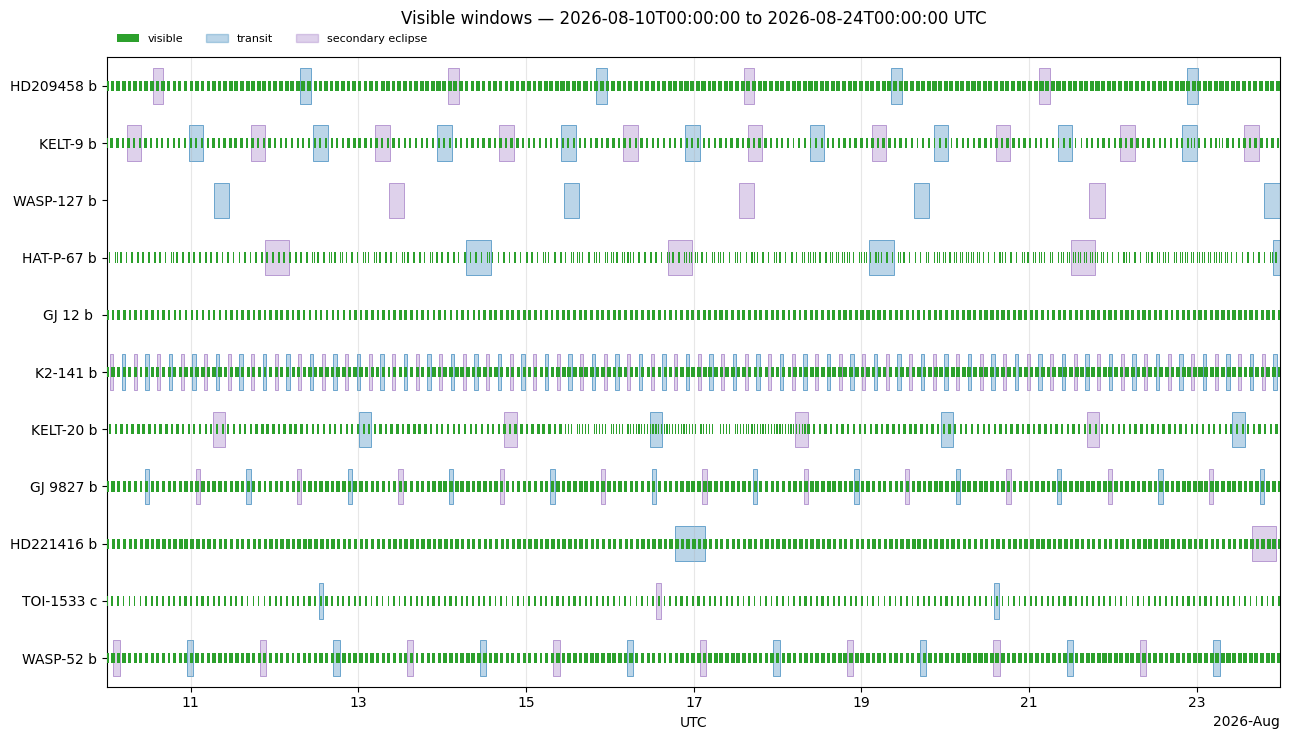

In [4]:
fig, ax = plt.subplots(figsize=(13, 0.5 * len(results) + 2.0))

for row, result in enumerate(results.values()):
    for kind, color in (("transit", TRANSIT_COLOR), ("eclipse", ECLIPSE_COLOR)):
        events = result["events"].get(kind)
        if events:
            draw_event_box(
                ax, row,
                event_segments(events, min_width_minutes=time_step_minutes),
                color,
            )
    draw_row(
        ax, row,
        mask_segments(times, result["visible"], time_step_minutes),
        "tab:green",
    )

label_rows(ax, list(results))
format_date_axis(ax, times)
ax.set_title(f"Visible windows — {start_utc} to {stop_utc} UTC", pad=24)

handles = [Patch(facecolor="tab:green", label="visible")]
if any(result["events"] for result in results.values()):
    handles += [
        Patch(facecolor=TRANSIT_COLOR, alpha=0.30, edgecolor=TRANSIT_COLOR,
              label="transit"),
        Patch(facecolor=ECLIPSE_COLOR, alpha=0.30, edgecolor=ECLIPSE_COLOR,
              label="secondary eclipse"),
    ]
ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.0, 1.005),
          ncols=len(handles), fontsize=8, frameon=False)
plt.tight_layout()

## Which constraint is failing?

For each target, a red bar marks the time steps where that individual
constraint fails; the grey row at the bottom is the overall "not visible"
result for comparison.

`get_all_constraints` shares its ephemeris and geometry with `get_visibility`,
so the boresight rows account for every boresight failure exactly.  The star
tracker row is different: it is evaluated at the default Sun-constrained
attitude, one step at a time, while the grey row comes from
`get_visibility_best_roll`, which holds a single roll angle for a whole orbit.
A step can therefore be marked not visible while every row here passes — the
orbit's fixed roll failed a tracker even though a per-step attitude would not
have.  The printout counts those.

HD209458 b: not visible at 620 of 2016 steps
    moon         fails at     0 steps
    sun          fails at     0 steps
    earthlimb    fails at   322 steps
    star_tracker fails at   652 steps
    285 not-visible steps not explained by the above
KELT-9 b: not visible at 1200 of 2016 steps
    moon         fails at     0 steps
    sun          fails at     0 steps
    earthlimb    fails at   694 steps
    star_tracker fails at   559 steps
    346 not-visible steps not explained by the above
WASP-127 b: not visible at 2016 of 2016 steps
    moon         fails at   361 steps
    sun          fails at  2016 steps
    earthlimb    fails at  1523 steps
    star_tracker fails at   631 steps
HAT-P-67 b: not visible at 1403 of 2016 steps
    moon         fails at     0 steps
    sun          fails at     0 steps
    earthlimb    fails at   944 steps
    star_tracker fails at   463 steps
    84 not-visible steps not explained by the above
GJ 12 b : not visible at 975 of 2016 steps
    moon  

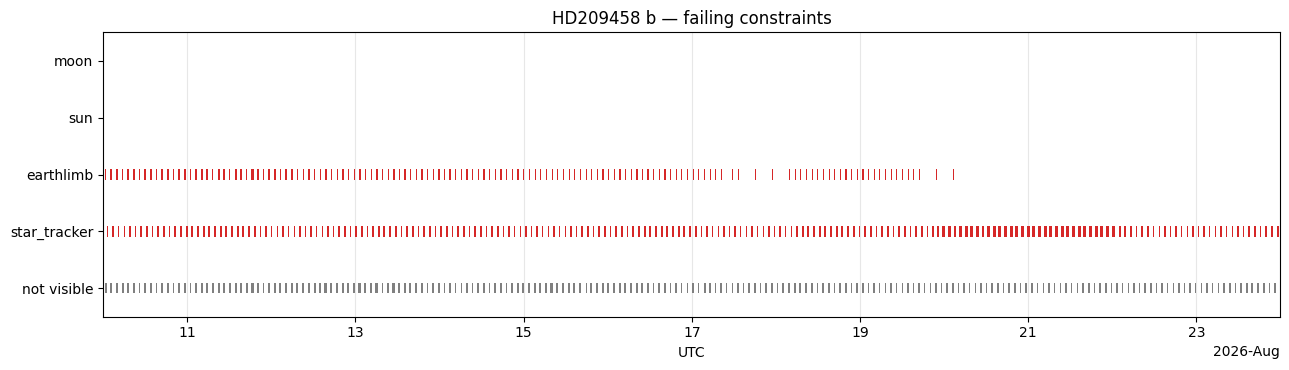

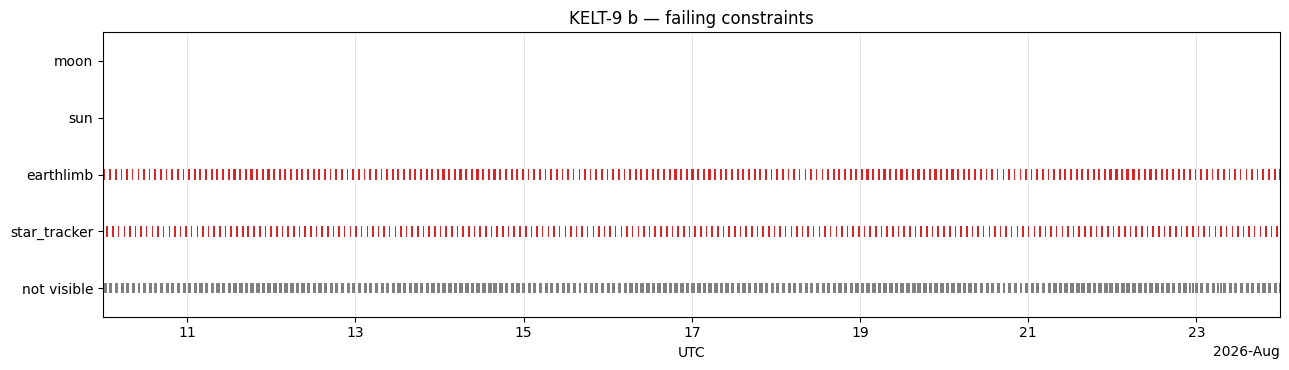

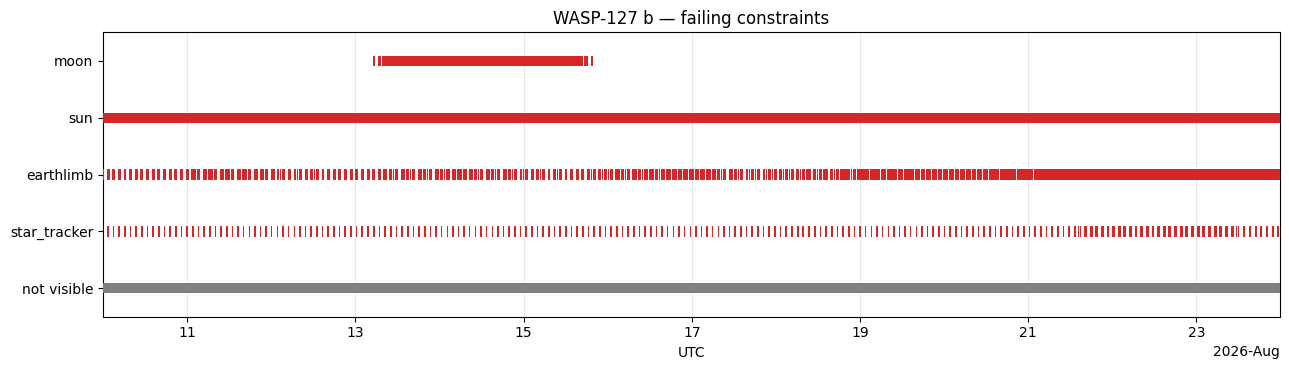

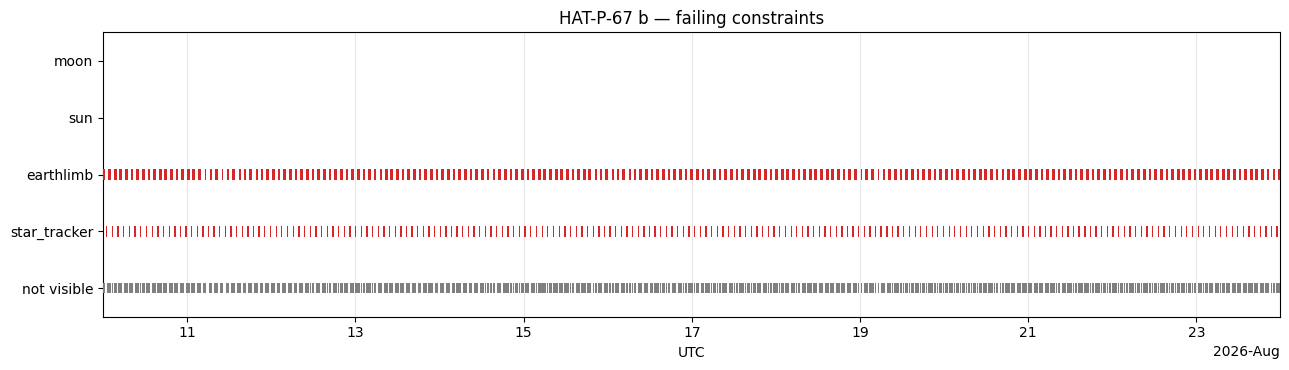

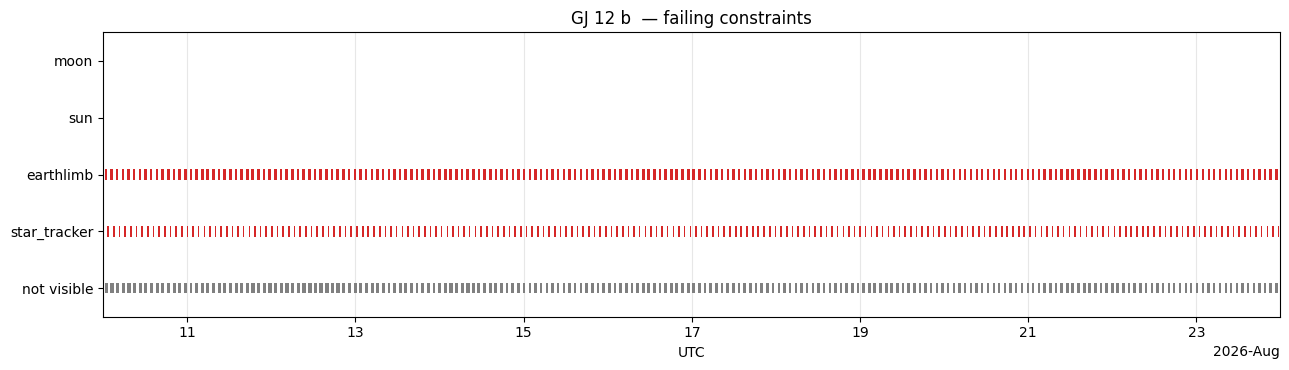

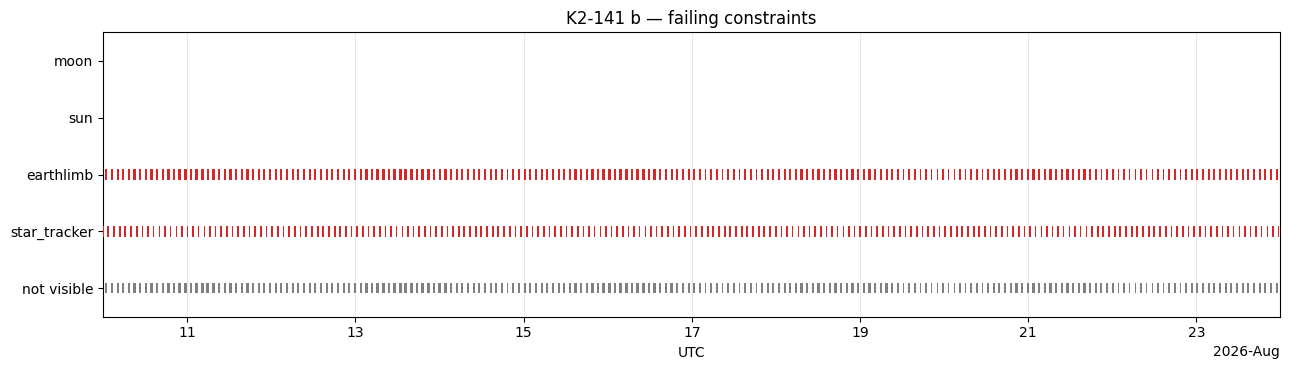

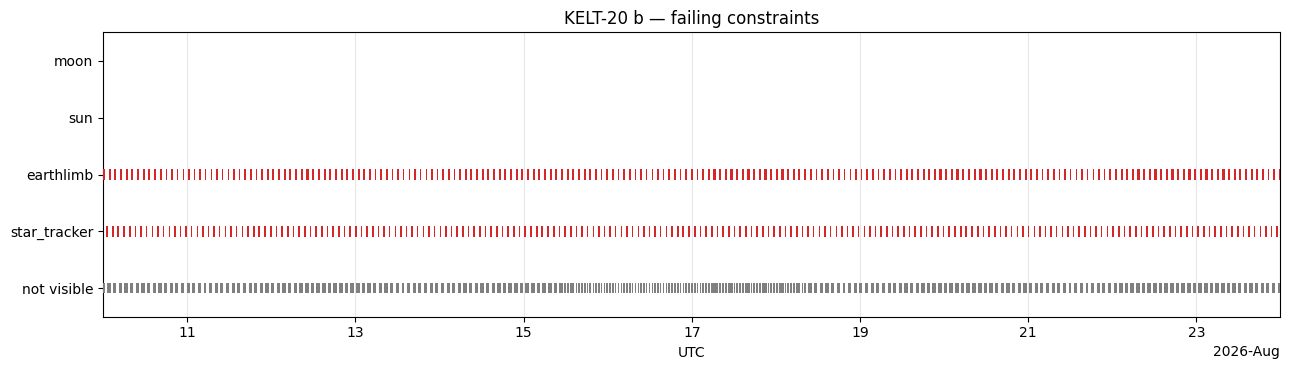

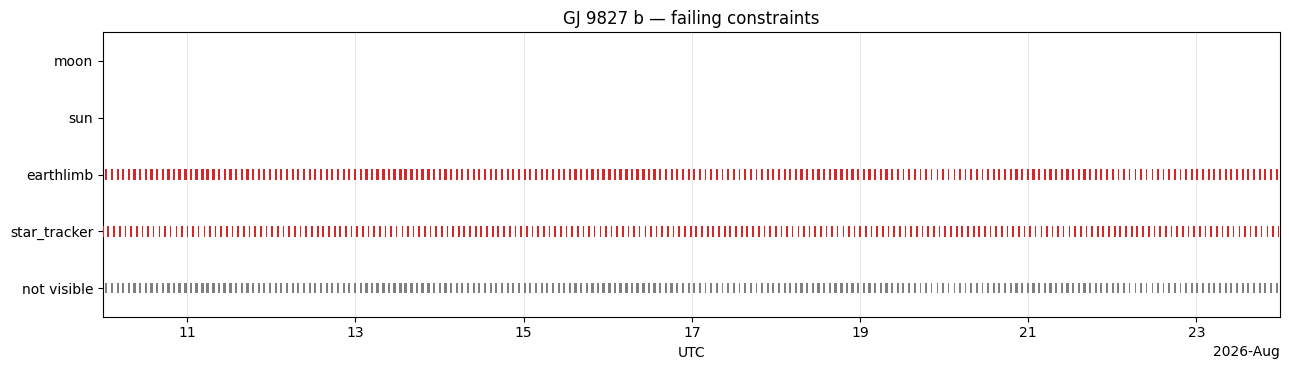

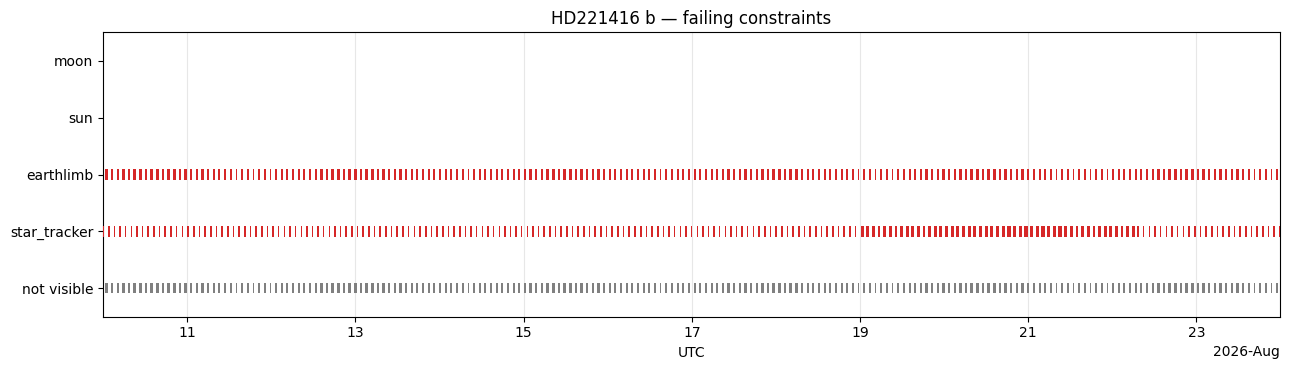

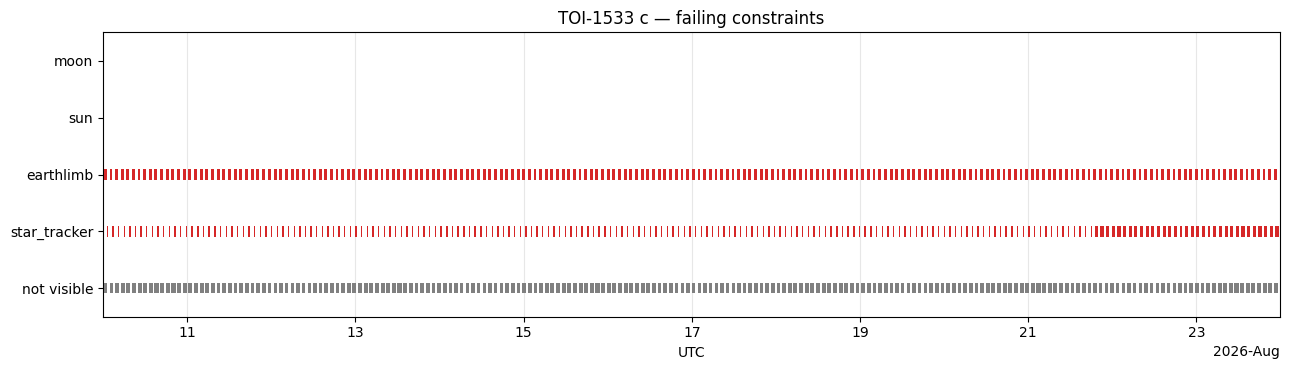

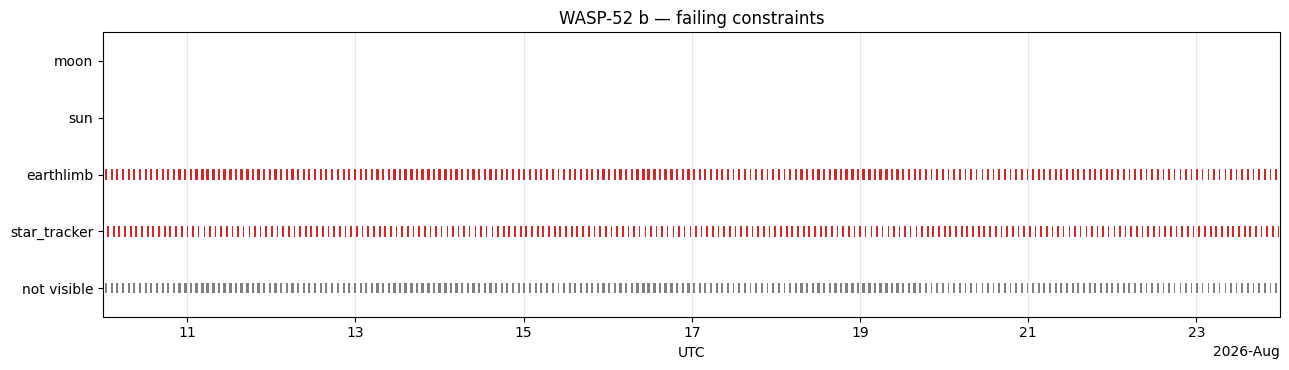

In [5]:
for label, result in results.items():
    constraints = visibility.get_all_constraints(result["coord"], times)
    failures = {
        name: ~np.asarray(passed) for name, passed in constraints.items()
    }
    not_visible = ~result["visible"]

    explained = np.zeros_like(not_visible)
    for fail_mask in failures.values():
        explained |= fail_mask
    unexplained = int(np.sum(not_visible & ~explained))

    rows = list(failures) + ["not visible"]
    fig, ax = plt.subplots(figsize=(13, 0.4 * len(rows) + 1.8))
    for row, name in enumerate(failures):
        draw_row(
            ax, row,
            mask_segments(times, failures[name], time_step_minutes),
            "tab:red",
        )
    draw_row(
        ax, len(rows) - 1,
        mask_segments(times, not_visible, time_step_minutes),
        "0.5",
    )

    label_rows(ax, rows)
    format_date_axis(ax, times)
    ax.set_title(f"{label} — failing constraints")
    plt.tight_layout()

    print(f"{label}: not visible at {int(not_visible.sum())} of {len(times)} steps")
    for name, fail_mask in failures.items():
        print(f"    {name:<12} fails at {int(fail_mask.sum()):>5} steps")
    if unexplained:
        print(f"    {unexplained} not-visible steps not explained by the above")